<a href="https://colab.research.google.com/github/gyumin125/25-2-DIP-202302456/blob/main/HW/HW08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nibabel

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.ndimage as nd
from skimage.morphology import disk , opening, erosion, closing
from PIL import Image

In [3]:
h1 = nib.load('s01.nii.gz')
h2 = nib.load('s02.nii.gz')


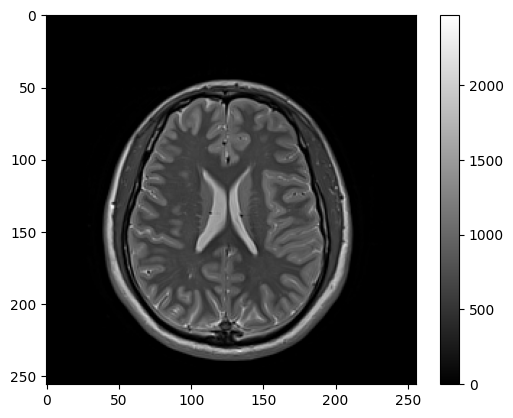

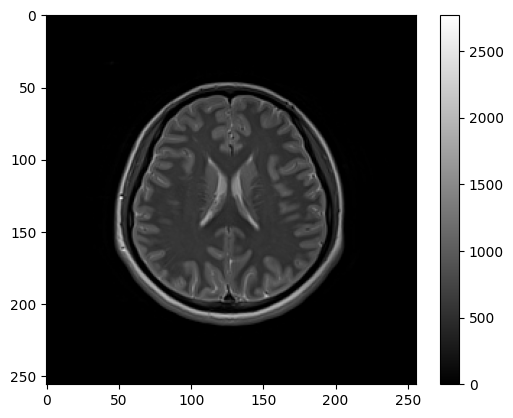

In [4]:
mri1 = h1.get_fdata()
mri2 = h2.get_fdata()
f1 = mri1[::-1,::-1,23].transpose((1,0))
f2 = mri2[::-1,::-1,22].transpose((1,0))
plt.imshow(f1,cmap='gray')
plt.colorbar()
plt.show()
plt.imshow(f2,cmap='gray')
plt.colorbar()
plt.show()

In [5]:
def global_thresholding(f):
  T_init = 128
  T = []
  T.append(T_init)
  dT = 1000
  esp = 2

  while dT > esp:
      current_T = T[-1]

      g1 = f[f > current_T]
      g2 = f[f<= current_T]

      m1 = np.mean(g1) if len(g1) > 0 else 0
      m2 = np.mean(g2) if len(g2) > 0 else 0

      new_T = (m1 + m2) / 2
      T.append(new_T)

      dT = np.abs(T[-1] - T[-2])


  print(f"Final Threshold: {T[-1]:.2f}")
  print(f"Iterations: {len(T)-1}")

  bmsk = f > T[-1]
  bmsk=opening(bmsk,disk(6))
  bmsk=closing(bmsk,disk(4))
  segmented_area = np.sum(bmsk)
  print(f"분할된 부분의 면적 (픽셀 수): {segmented_area}")
  plt.figure(figsize=(10, 5))
  plt.subplot(121)
  plt.imshow(f, cmap='gray')
  plt.axis('off')
  plt.title('Original Image')
  plt.subplot(122)
  plt.imshow(bmsk, cmap='gray')
  plt.axis('off')
  plt.title(f'Final Result (th: {T[-1]:.2f})')

  plt.tight_layout()
  plt.show()

Final Threshold: 434.92
Iterations: 4
분할된 부분의 면적 (픽셀 수): 17783


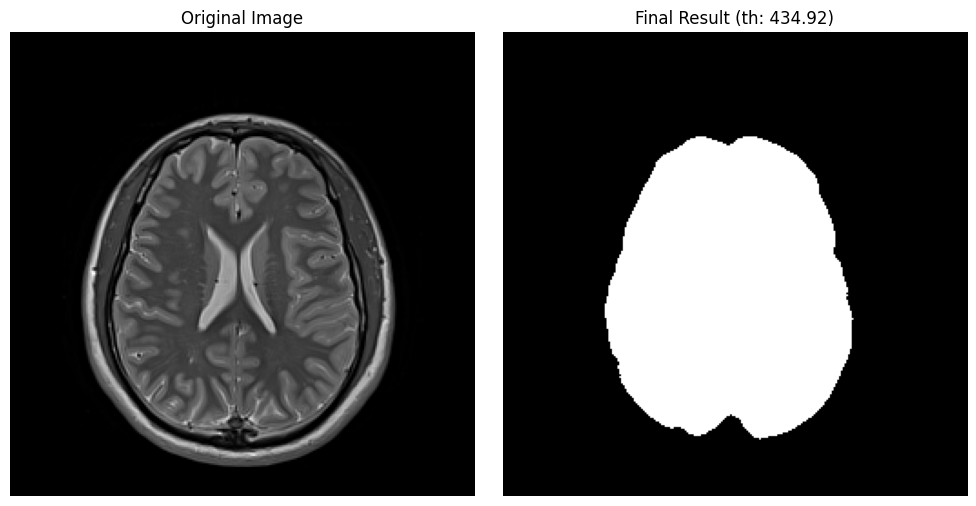

In [6]:
global_thresholding(f1)

Final Threshold: 392.51
Iterations: 3
분할된 부분의 면적 (픽셀 수): 15337


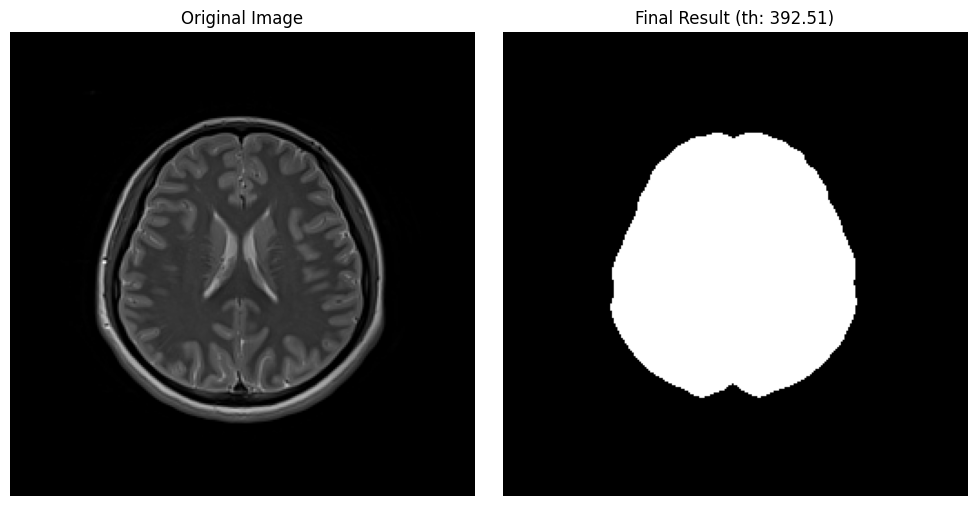

In [7]:
global_thresholding(f2)

In [8]:
def k_mean(k,eps,img):
  m_vals=np.random.randint(0,img.max(),size=k).astype(float)
  labels=np.zeros_like(img,dtype=int)
  max_iter=100
  for it in range(max_iter):
    old_means=m_vals.copy()
    for i in range(img.shape[0]):
      for j in range(img.shape[1]):
        val = img[i,j]
        dists=np.abs(val-m_vals)
        labels[i,j]=np.argmin(dists)
    for l in range(k):
      mask=(labels==l)
      if np.any(mask):
        m_vals[l]=img[mask].mean()
      else :
        m_vals[l]=old_means[l]
    diff=np.sum(np.abs(m_vals-old_means))
    if diff<eps:
      break
  return labels,m_vals

In [9]:

labels1,m_vals1=k_mean(3,1,f1)
labels2,m_vals2=k_mean(3,1,f2)

unique_labels1, counts = np.unique(labels1, return_counts=True)
min_area_label1 = unique_labels1[np.argmin(counts)]
seg_label1 = labels1 == min_area_label1
unique_labels2, counts = np.unique(labels2, return_counts=True)
min_area_label2 = unique_labels2[np.argmin(counts)]
seg_label2 = labels2 == min_area_label2

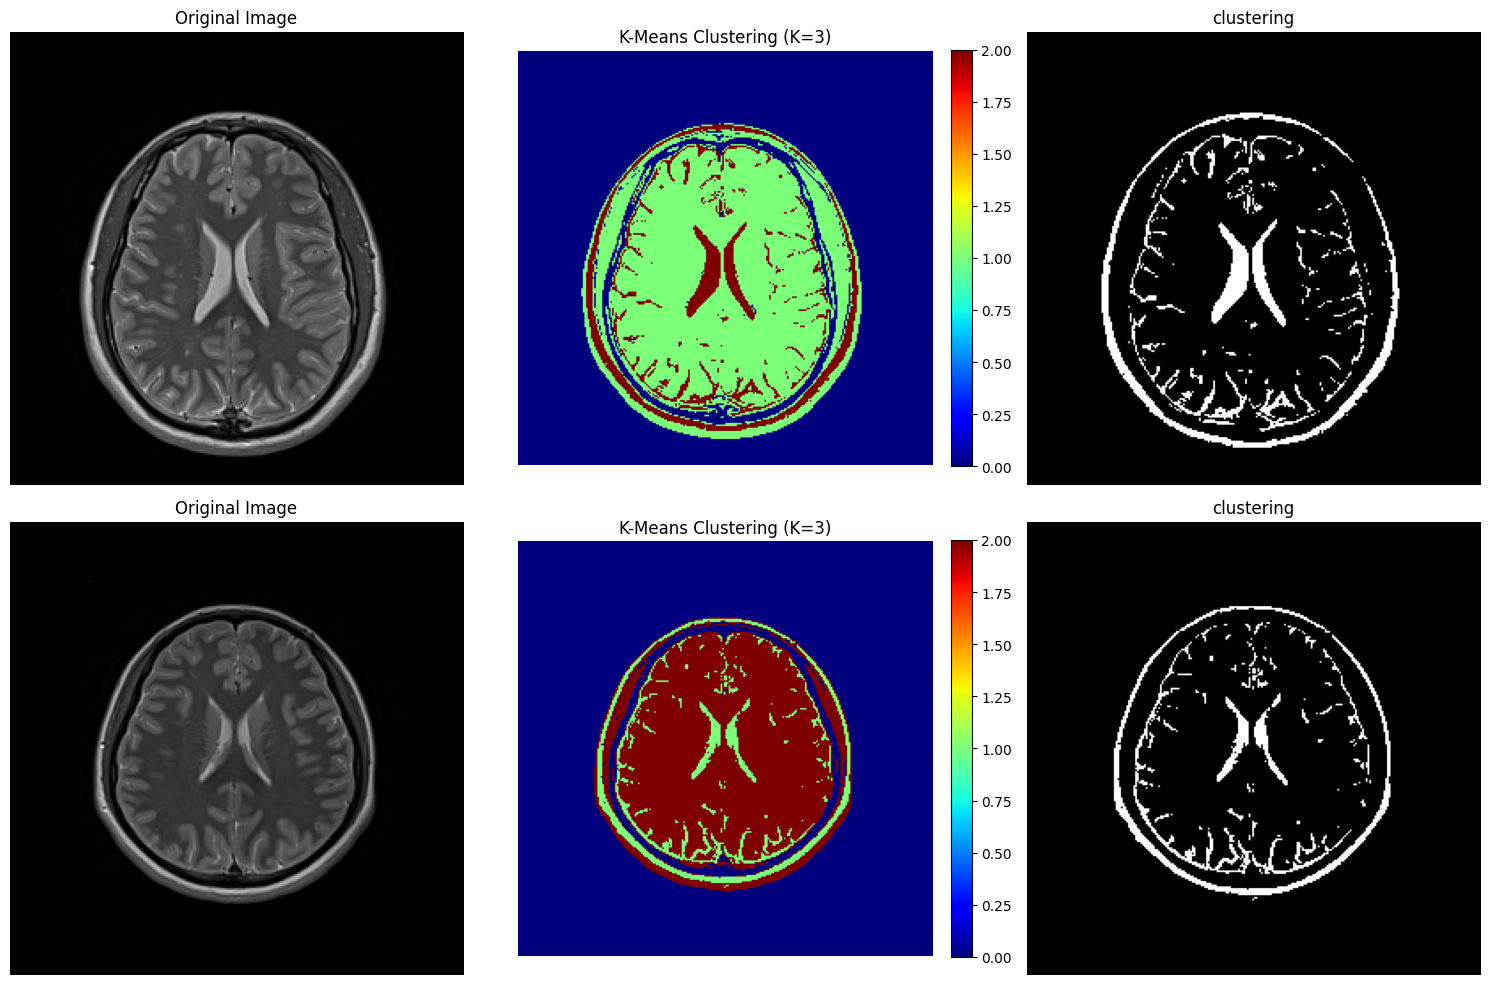

<Figure size 640x480 with 0 Axes>

In [10]:

plt.figure(figsize=(15,10))

plt.subplot(231)
plt.imshow(f1, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(232)
plt.imshow(labels1, cmap='jet')
plt.title(f'K-Means Clustering (K=3)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')


plt.subplot(233)
plt.imshow(seg_label1, cmap='gray')
plt.title(f'clustering')
plt.axis('off')

plt.subplot(234)
plt.imshow(f2, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(235)
plt.imshow(labels2, cmap='jet')
plt.title(f'K-Means Clustering (K=3)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(236)
plt.imshow(seg_label2, cmap='gray')
plt.title(f'clustering')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


In [11]:
def remove_largest_object(mask):
    labeled_array, num_features = nd.label(mask)

    if num_features == 0:
        return mask.copy()
    counts = np.bincount(labeled_array.ravel())
    counts[0] = 0
    largest_label = counts.argmax()

    out_mask = mask.copy()
    out_mask[labeled_array == largest_label] = False

    return out_mask


In [12]:
def keep_large_components(mask, min_area):
    lbl, num = nd.label(mask)
    if num == 0:
        return np.zeros_like(mask, dtype=bool)

    counts = np.bincount(lbl.ravel())
    counts[0] = 0
    out = np.zeros_like(mask, dtype=bool)
    valid_labels = np.where(counts >= min_area)[0]
    for lab in valid_labels:
        out[lbl == lab] = True

    return out

분할된 부분의 면적 (픽셀 수): 810
분할된 부분의 면적 (픽셀 수): 456


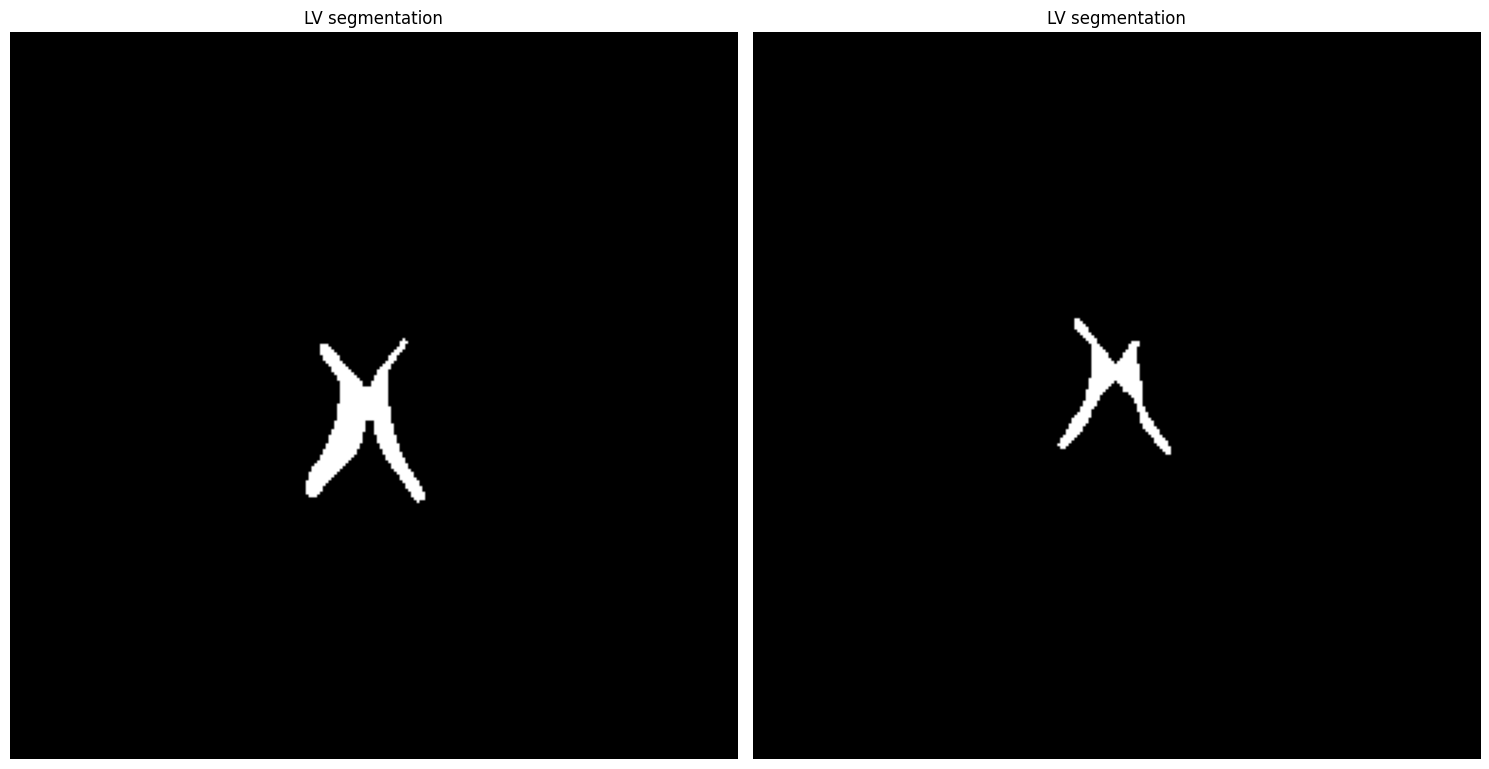

In [13]:

seg_removed1 = remove_largest_object(seg_label1)
seg_removed2 = remove_largest_object(seg_label2)
img_blur1 = nd.median_filter(seg_removed1, size=5)
seg_final1 = keep_large_components(img_blur1, 500)
img_blur2 = nd.median_filter(seg_removed2, size=4)
seg_close2 = closing(img_blur2, disk(2))
seg_final2 = keep_large_components(seg_close2, 400)

segmented_area1 = np.sum(seg_final1)
segmented_area2 = np.sum(seg_final2)
print(f"분할된 부분의 면적 (픽셀 수): {segmented_area1}")
print(f"분할된 부분의 면적 (픽셀 수): {segmented_area2}")
plt.figure(figsize=(15,10))
plt.subplot(121)
plt.imshow(seg_final1, cmap='gray')
plt.title('LV segmentation')
plt.axis('off')
plt.subplot(122)
plt.imshow(seg_final2, cmap='gray')
plt.title(f'LV segmentation')
plt.axis('off')
plt.tight_layout()
plt.show()